# Screen Time Behaviour Analysis – Neural Network Classification

**Objective:** Classify daily screen time behaviour (Low / Moderate / High) based on user attributes.

**Target (Y):** `Daily_Screen_Time_Hours` — Low (≤3 h), Moderate (3–6 h), High (>6 h)

**Dataset:** Global Video Screen Time Analysis – 20,000 records, 16 attributes

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Correlation Matrix
3. **Feature Selection — top 6 features via Mutual Information**
4. Preprocessing (StandardScaler on selected features)
5. Train-Test Split (80/20 stratified)
6. Neural Network with L2 Regularization + Dropout
7. Train for 10 Epochs → Check Overfitting → Increase to 15 if needed
8. Confusion Matrix
9. Accuracy · Precision · Recall · F1 Score · Error Rate

## Step 0 – Load Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 100
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv('Global_Video_Screen_Time_Analysis_20000_Rows.csv')
print('Shape:', df.shape)
df.head()

Shape: (20000, 15)


,Country,Age_Group,Gender,Daily_Screen_Time_Hours,Peak_Viewing_Hour,Content_Category,Device_Type,Subscription_Type,Platform,Weekly_Sessions,Average_Session_Duration_Minutes,Number_of_Platforms_Used,Internet_Connection,Content_Language_Preference,Binge_Watch_Frequency
0,China,Adults,Male,Moderate,20,Animation,Smart TV,Basic,TikTok,14,31,3,Broadband,Chinese,Never
1,Philippines,Adults,Female,High,23,Animation,Tablet,Basic,Netflix,22,60,4,Fiber,English,Weekly
2,United States,Adults,Male,High,20,Sci-Fi,Mobile,Free,Disney+,22,55,4,Fiber,Arabic,Multiple Times Per Week
3,Malaysia,Adults,Male,High,23,Horror,Mobile,Standard,Amazon Prime Video,22,54,3,Fiber,Hindi,2-3 Times Per Week
4,Israel,Young Adults,Female,High,18,Animation,Desktop,Basic,Amazon Prime Video,20,66,2,ADSL,English,Never


## Step 1 – Exploratory Data Analysis (EDA)

In [3]:
# Basic information about each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Country                           20000 non-null  str  
 1   Age_Group                         20000 non-null  str  
 2   Gender                            20000 non-null  str  
 3   Daily_Screen_Time_Hours           20000 non-null  str  
 4   Peak_Viewing_Hour                 20000 non-null  int64
 5   Content_Category                  20000 non-null  str  
 6   Device_Type                       20000 non-null  str  
 7   Subscription_Type                 20000 non-null  str  
 8   Platform                          20000 non-null  str  
 9   Weekly_Sessions                   20000 non-null  int64
 10  Average_Session_Duration_Minutes  20000 non-null  int64
 11  Number_of_Platforms_Used          20000 non-null  int64
 12  Internet_Connection               20000 non

In [4]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total missing cells:', df.isnull().sum().sum())

Missing values per column:
Country                             0
Age_Group                           0
Gender                              0
Daily_Screen_Time_Hours             0
Peak_Viewing_Hour                   0
Content_Category                    0
Device_Type                         0
Subscription_Type                   0
Platform                            0
Weekly_Sessions                     0
Average_Session_Duration_Minutes    0
Number_of_Platforms_Used            0
Internet_Connection                 0
Content_Language_Preference         0
Binge_Watch_Frequency               0
dtype: int64

Total missing cells: 0


In [5]:
print('Target variable distribution:')
print(df['Daily_Screen_Time_Hours'].value_counts())
print()
print('Class balance (%):\n', df['Daily_Screen_Time_Hours'].value_counts(normalize=True).mul(100).round(1))

Target variable distribution:
Daily_Screen_Time_Hours
High        15137
Moderate     4863
Name: count, dtype: int64

Class balance (%):
 Daily_Screen_Time_Hours
High        75.7
Moderate    24.3
Name: proportion, dtype: float64


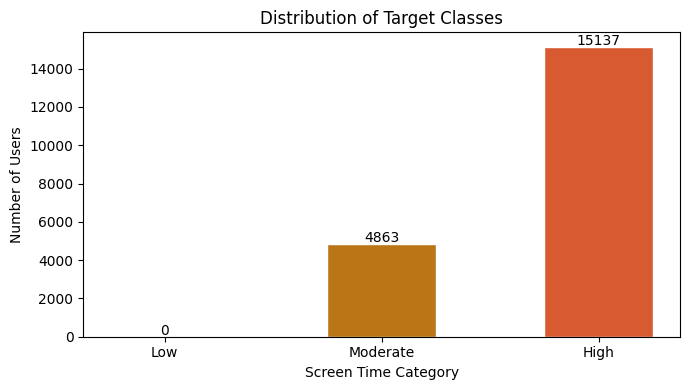

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
order  = ['Low', 'Moderate', 'High']
colors = ['#1D9E75', '#BA7517', '#D85A30']
counts = [df['Daily_Screen_Time_Hours'].value_counts().get(c, 0) for c in order]
bars   = ax.bar(order, counts, color=colors, edgecolor='white', width=0.5)
ax.set_xlabel('Screen Time Category')
ax.set_ylabel('Number of Users')
ax.set_title('Distribution of Target Classes')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 80, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
categorical_cols = ['Age_Group', 'Gender', 'Country', 'Content_Category',
                    'Device_Type', 'Subscription_Type', 'Platform',
                    'Internet_Connection', 'Binge_Watch_Frequency']
for col in categorical_cols:
    vals = sorted(df[col].dropna().unique().tolist())
    print(f'{col}: {df[col].nunique()} categories -> {vals}')

Age_Group: 3 categories -> ['Adults', 'Children', 'Young Adults']
Gender: 2 categories -> ['Female', 'Male']
Country: 44 categories -> ['Argentina', 'Australia', 'Bangladesh', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Ecuador', 'Egypt', 'Ethiopia', 'France', 'Germany', 'Ghana', 'India', 'Indonesia', 'Israel', 'Italy', 'Japan', 'Kenya', 'Malaysia', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway', 'Pakistan', 'Peru', 'Philippines', 'Qatar', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Thailand', 'Tunisia', 'Turkey', 'United Arab Emirates', 'United Kingdom', 'United States', 'Vietnam']
Content_Category: 10 categories -> ['Action', 'Animation', 'Comedy', 'Documentary', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Sports', 'Thriller']
Device_Type: 4 categories -> ['Desktop', 'Mobile', 'Smart TV', 'Tablet']
Subscription_Type: 4 categories -> ['Basic', 'Free', 'Premium', 'Standard']
Platform: 6 categories -> ['Amazon Prime Video', '

## Step 2 – Correlation Matrix

We encode all features numerically and compute pairwise Pearson correlations.  
Features with high absolute correlation to `Target_enc` are the most informative for classification.

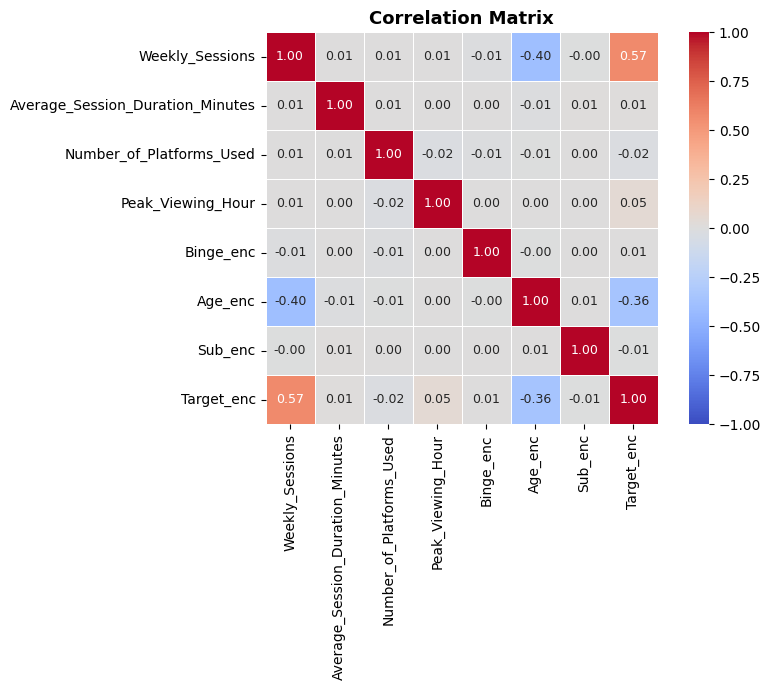


Correlation with Target (screen time category):
Weekly_Sessions                     0.572
Age_enc                            -0.358
Peak_Viewing_Hour                   0.048
Number_of_Platforms_Used           -0.016
Average_Session_Duration_Minutes    0.010
Sub_enc                            -0.005
Binge_enc                           0.005
Name: Target_enc, dtype: float64


In [8]:
# Encode target and ordered categoricals for correlation analysis
target_map  = {'Low': 0, 'Moderate': 1, 'High': 2}
binge_order = {'Never': 0, 'Monthly': 1, 'Weekly': 2,
               '2-3 Times Per Week': 3, 'Multiple Times Per Week': 4, 'Daily': 5}
age_map     = {'Children': 0, 'Young Adults': 1, 'Adults': 2}
sub_map     = {'Free': 0, 'Basic': 1, 'Standard': 2, 'Premium': 3}

df['Target_enc'] = df['Daily_Screen_Time_Hours'].map(target_map)
df['Binge_enc']  = df['Binge_Watch_Frequency'].map(binge_order)
df['Age_enc']    = df['Age_Group'].map(age_map)
df['Sub_enc']    = df['Subscription_Type'].map(sub_map)

corr_cols = ['Weekly_Sessions', 'Average_Session_Duration_Minutes',
             'Number_of_Platforms_Used', 'Peak_Viewing_Hour',
             'Binge_enc', 'Age_enc', 'Sub_enc', 'Target_enc']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with Target (screen time category):')
print(corr_matrix['Target_enc'].drop('Target_enc').sort_values(key=abs, ascending=False).round(3))

## Step 3 – Feature Selection (Top 6 Features)

We score every feature using **Mutual Information** — how much knowing that feature reduces uncertainty about the target class. This works for both linear and non-linear relationships, unlike Pearson correlation.

Only the **top 6 features** are kept for all subsequent steps, reducing noise and keeping the neural network focused on the most predictive signals.

Mutual Information Scores (higher = more predictive of Y):
Weekly_Sessions                0.1856
Country                        0.1398
Age_Group                      0.1007
Platform                       0.0057
Content_Language_Preference    0.0040
Num_Platforms_Used             0.0038
Subscription_Type              0.0038
Device_Type                    0.0028
Internet_Connection            0.0026
Peak_Viewing_Hour              0.0018
Content_Category               0.0014
Gender                         0.0000
Avg_Session_Duration_Min       0.0000
Binge_Frequency                0.0000


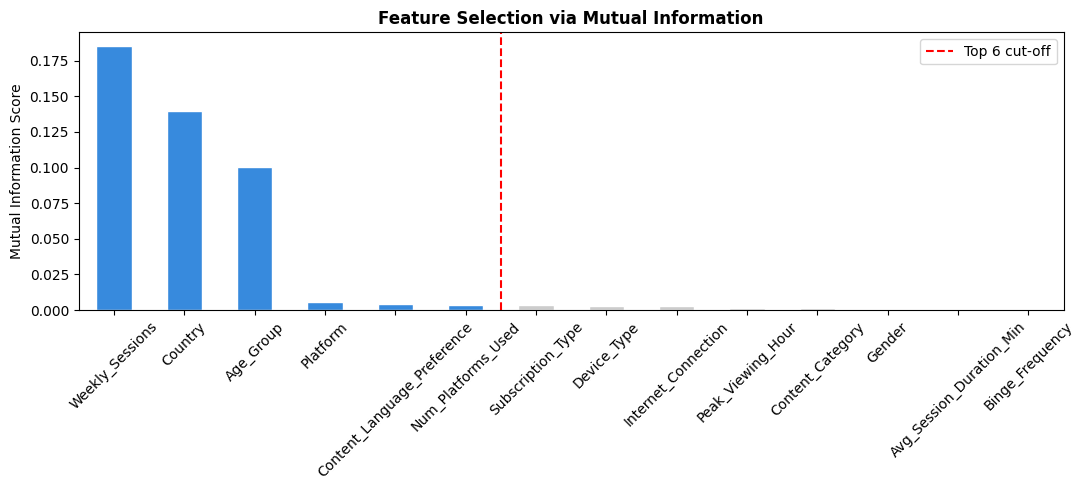


Selected top 6 features for model training:
  1. Weekly_Sessions  (MI = 0.1856)
  2. Country  (MI = 0.1398)
  3. Age_Group  (MI = 0.1007)
  4. Platform  (MI = 0.0057)
  5. Content_Language_Preference  (MI = 0.0040)
  6. Num_Platforms_Used  (MI = 0.0038)


In [9]:
# Build a complete feature pool (all numeric + label-encoded nominal)
feature_pool = pd.DataFrame({
    'Weekly_Sessions':          df['Weekly_Sessions'],
    'Avg_Session_Duration_Min': df['Average_Session_Duration_Minutes'],
    'Num_Platforms_Used':       df['Number_of_Platforms_Used'],
    'Peak_Viewing_Hour':        df['Peak_Viewing_Hour'],
    'Binge_Frequency':          df['Binge_enc'],
    'Age_Group':                df['Age_enc'],
    'Subscription_Type':        df['Sub_enc'],
})

for col in ['Gender', 'Country', 'Device_Type', 'Content_Category',
            'Platform', 'Internet_Connection', 'Content_Language_Preference']:
    le = LabelEncoder()
    feature_pool[col] = le.fit_transform(df[col].astype(str))

y_target = df['Target_enc'].values

# Compute Mutual Information score for each feature vs target
mi_scores = mutual_info_classif(feature_pool, y_target, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=feature_pool.columns).sort_values(ascending=False)

print('Mutual Information Scores (higher = more predictive of Y):')
print(mi_series.round(4).to_string())

TOP_K = 6
top_features = mi_series.head(TOP_K).index.tolist()

# Bar chart — top 6 highlighted in blue, rest in grey
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#378ADD' if i < TOP_K else '#cccccc' for i in range(len(mi_series))]
mi_series.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(TOP_K - 0.5, color='red', linestyle='--', linewidth=1.5, label=f'Top {TOP_K} cut-off')
ax.set_title('Feature Selection via Mutual Information', fontsize=12, fontweight='bold')
ax.set_ylabel('Mutual Information Score')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nSelected top {TOP_K} features for model training:')
for i, f in enumerate(top_features, 1):
    print(f'  {i}. {f}  (MI = {mi_series[f]:.4f})')

## Step 4 – Preprocessing

We build the final feature matrix using **only the top 6 selected features** from the mutual information step, then apply **StandardScaler** (neural networks require scaled inputs).

In [10]:
# Use only the top 6 features identified by Mutual Information
X = feature_pool[top_features].astype(float)
y = df['Target_enc'].values   # 0 = Low, 1 = Moderate, 2 = High

print(f'Feature matrix shape : {X.shape}  ({TOP_K} features × {len(X)} rows)')
print(f'Features used        : {top_features}')
print(f'Target classes       : 0 = Low | 1 = Moderate | 2 = High')
print(f'Class counts         : {np.bincount(y)}')

Feature matrix shape : (20000, 6)  (6 features × 20000 rows)
Features used        : ['Weekly_Sessions', 'Country', 'Age_Group', 'Platform', 'Content_Language_Preference', 'Num_Platforms_Used']
Target classes       : 0 = Low | 1 = Moderate | 2 = High
Class counts         : [    0  4863 15137]


## Step 5 – Train-Test Split

80% training / 20% testing with **stratification** so all three classes (Low, Moderate, High) are proportionally represented in both sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print('Training samples :', X_train_sc.shape[0])
print('Testing  samples :', X_test_sc.shape[0])
print()
print('Class distribution in train:', np.bincount(y_train))
print('Class distribution in test :', np.bincount(y_test))

Training samples : 16000
Testing  samples : 4000

Class distribution in train: [    0  3890 12110]
Class distribution in test : [   0  973 3027]


## Step 6 – Neural Network with Regularization

**Architecture:** Input(6) → Dense(128) → Dense(64) → Dense(32) → Output(3, softmax)

**Regularization techniques used:**
- **L2 regularization** (`λ = 0.001`) on every Dense layer — penalises large weights and discourages memorising noise
- **Dropout (30%)** — randomly disables 30% of neurons per step, forcing robust representations

Both methods reduce overfitting and improve generalisation to unseen data.

In [12]:
def build_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim,
              kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(32, activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
        Dense(3, activation='softmax')   # 3 output classes: Low, Moderate, High
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(X_train_sc.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,331 (44.26 KB)

 Trainable params: 11,331 (44.26 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 – Train for 10 Epochs

15% of the training data is held out as a **validation set** so we can monitor overfitting after each epoch.

In [13]:
history_10 = model.fit(
    X_train_sc, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8051 - loss: 0.5619 - val_accuracy: 0.8546 - val_loss: 0.4519
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8395 - loss: 0.4492 - val_accuracy: 0.8554 - val_loss: 0.4186
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8418 - loss: 0.4193 - val_accuracy: 0.8533 - val_loss: 0.3994
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8441 - loss: 0.4043 - val_accuracy: 0.8558 - val_loss: 0.3857
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8454 - loss: 0.3918 - val_accuracy: 0.8533 - val_loss: 0.3777
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8490 - loss: 0.3810 - val_accuracy: 0.8537 - val_loss: 0.3700
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8490 - loss: 0.3764 - val_accuracy: 0.8533 - val_loss: 0.3642
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8515 - loss: 0.3693 - val_acc

## Step 8 – Check Overfitting

Plot training vs validation accuracy and loss.  
**Overfitting** is flagged when the final train accuracy exceeds validation accuracy by more than 5 percentage points.

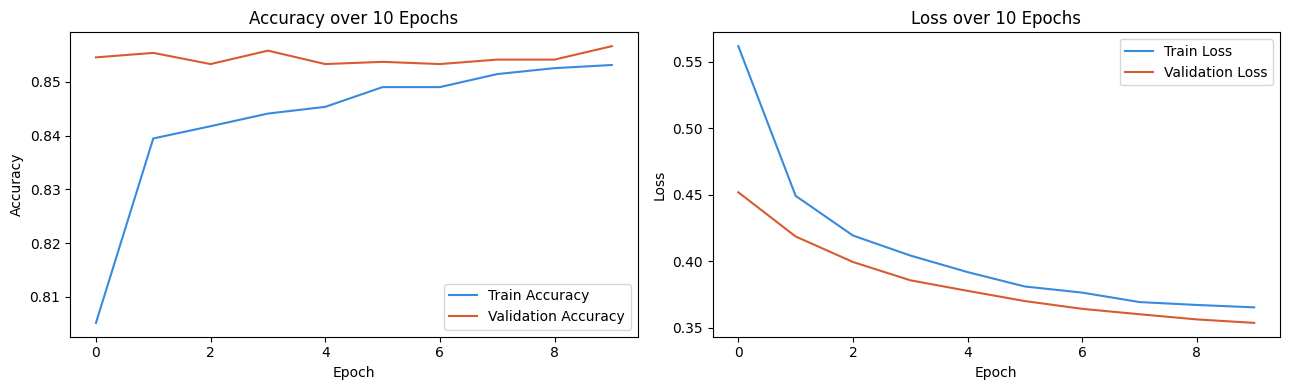

Train Accuracy     : 0.8532
Validation Accuracy: 0.8567
Gap (Train - Val)  : -0.0035

No significant overfitting (gap ≤ 0.05) — 10-epoch model is sufficient.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_10.history['accuracy'],     label='Train Accuracy',      color='#378ADD')
axes[0].plot(history_10.history['val_accuracy'], label='Validation Accuracy', color='#D85A30')
axes[0].set_title('Accuracy over 10 Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_10.history['loss'],     label='Train Loss',      color='#378ADD')
axes[1].plot(history_10.history['val_loss'], label='Validation Loss', color='#D85A30')
axes[1].set_title('Loss over 10 Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

final_train_acc = history_10.history['accuracy'][-1]
final_val_acc   = history_10.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f'Train Accuracy     : {final_train_acc:.4f}')
print(f'Validation Accuracy: {final_val_acc:.4f}')
print(f'Gap (Train - Val)  : {gap:.4f}')

if gap > 0.05:
    print('\nOverfitting DETECTED (gap > 0.05) — will retrain for 15 epochs.')
    overfitting = True
else:
    print('\nNo significant overfitting (gap ≤ 0.05) — 10-epoch model is sufficient.')
    overfitting = False

## Step 9 – Increase to 15 Epochs (if overfitting detected)

If overfitting was detected, we rebuild the model from scratch and train for 15 epochs.

In [15]:
if overfitting:
    print('Retraining for 15 epochs...\n')
    model = build_model(X_train_sc.shape[1])
    history_final = model.fit(
        X_train_sc, y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.15,
        verbose=1
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_final.history['accuracy'],     label='Train Accuracy',      color='#378ADD')
    axes[0].plot(history_final.history['val_accuracy'], label='Validation Accuracy', color='#D85A30')
    axes[0].set_title('Accuracy over 15 Epochs')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
    axes[1].plot(history_final.history['loss'],     label='Train Loss',      color='#378ADD')
    axes[1].plot(history_final.history['val_loss'], label='Validation Loss', color='#D85A30')
    axes[1].set_title('Loss over 15 Epochs')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print('No retraining needed — using the 10-epoch model.')
    history_final = history_10

No retraining needed — using the 10-epoch model.


## Step 10 – Confusion Matrix

Shows how many test samples were correctly and incorrectly classified for each class (Low / Moderate / High).

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


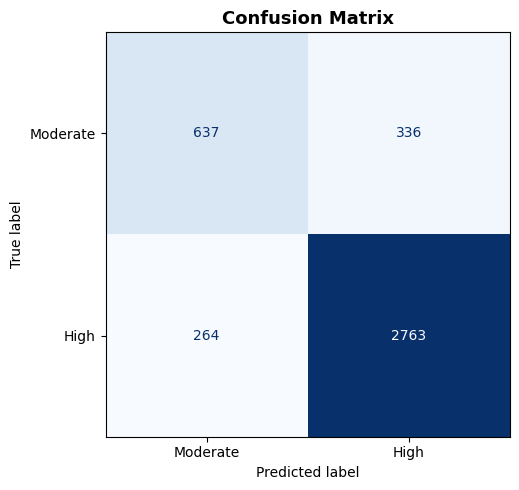

Confusion Matrix:
                 Predicted Moderate  Predicted High
Actual Moderate                 637             336
Actual High                     264            2763

Note: class(es) ['Low'] have no samples in the test set and are excluded.


In [16]:
y_pred_probs = model.predict(X_test_sc)
y_pred       = np.argmax(y_pred_probs, axis=1)

class_names  = ['Low', 'Moderate', 'High']
present_labels = sorted(np.unique(np.concatenate([y_test, y_pred])))
present_names  = [class_names[i] for i in present_labels]

cm = confusion_matrix(y_test, y_pred, labels=present_labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Confusion Matrix:')
print(pd.DataFrame(cm,
                   index=[f'Actual {c}'    for c in present_names],
                   columns=[f'Predicted {c}' for c in present_names]))
print()
if len(present_labels) < len(class_names):
    missing = [class_names[i] for i in range(len(class_names)) if i not in present_labels]
    print(f'Note: class(es) {missing} have no samples in the test set and are excluded.')

## Step 11 – Classification Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | Correct / Total | Overall fraction correct |
| **Precision** | TP / (TP + FP) | Of predicted positives, how many were truly positive |
| **Recall** | TP / (TP + FN) | Of actual positives, how many were found |
| **F1 Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |
| **Error Rate** | 1 − Accuracy | Fraction of wrong predictions |

All multi-class metrics use **weighted averaging** (accounts for class imbalance).

In [17]:
accuracy   = accuracy_score(y_test, y_pred)
precision  = precision_score(y_test, y_pred, average='weighted', labels=present_labels, zero_division=0)
recall     = recall_score(y_test, y_pred, average='weighted', labels=present_labels, zero_division=0)
f1         = f1_score(y_test, y_pred, average='weighted', labels=present_labels, zero_division=0)
error_rate = 1 - accuracy

print('=' * 47)
print('        CLASSIFICATION METRICS')
print('=' * 47)
print(f'  Accuracy   : {accuracy:.4f}   ({accuracy*100:.2f}%)')
print(f'  Precision  : {precision:.4f}')
print(f'  Recall     : {recall:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print(f'  Error Rate : {error_rate:.4f}   ({error_rate*100:.2f}%)')
print('=' * 47)
print()
print('Per-Class Breakdown:')
print(classification_report(y_test, y_pred,
                             labels=present_labels,
                             target_names=present_names,
                             zero_division=0))

        CLASSIFICATION METRICS
  Accuracy   : 0.8500   (85.00%)
  Precision  : 0.8467
  Recall     : 0.8500
  F1 Score   : 0.8480
  Error Rate : 0.1500   (15.00%)

Per-Class Breakdown:
              precision    recall  f1-score   support

    Moderate       0.71      0.65      0.68       973
        High       0.89      0.91      0.90      3027

    accuracy                           0.85      4000
   macro avg       0.80      0.78      0.79      4000
weighted avg       0.85      0.85      0.85      4000



## Step 12 – Direct Causes of High Screen Time

Identify which columns are directly responsible for driving screen time up, by comparing **High vs Moderate** users across every feature.

── Numeric Feature Averages: High vs Moderate ──
                         Weekly_Sessions  Average_Session_Duration_Minutes  Number_of_Platforms_Used  Peak_Viewing_Hour
Daily_Screen_Time_Hours                                                                                                
Moderate                           12.48                             42.71                      2.94              20.39
High                               18.40                             43.02                      2.90              20.58

── Difference (High − Moderate) ──
Weekly_Sessions                     5.92
Average_Session_Duration_Minutes    0.31
Peak_Viewing_Hour                   0.19
Number_of_Platforms_Used           -0.04


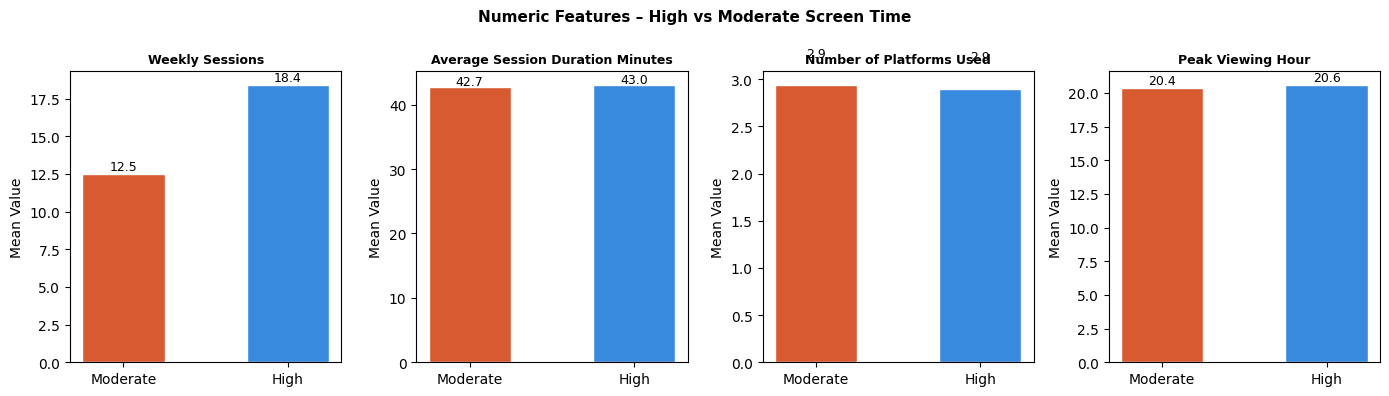


── Categorical Feature: Most Common Value per Class ──
  Binge_Watch_Frequency                  Moderate=Weekly                       High=2-3 Times Per Week  <-- DIFFERS
  Platform                               Moderate=TikTok                       High=Amazon Prime Video  <-- DIFFERS
  Age_Group                              Moderate=Adults                       High=Adults
  Device_Type                            Moderate=Desktop                      High=Desktop
  Subscription_Type                      Moderate=Standard                     High=Basic  <-- DIFFERS
  Internet_Connection                    Moderate=Broadband                    High=4G LTE  <-- DIFFERS
  Content_Category                       Moderate=Animation                    High=Comedy  <-- DIFFERS

── Binge Watch Frequency Distribution by Screen Time Class ──
Binge_Watch_Frequency    2-3 Times Per Week  Daily  Monthly  Multiple Times Per Week  Never  Weekly
Daily_Screen_Time_Hours                                

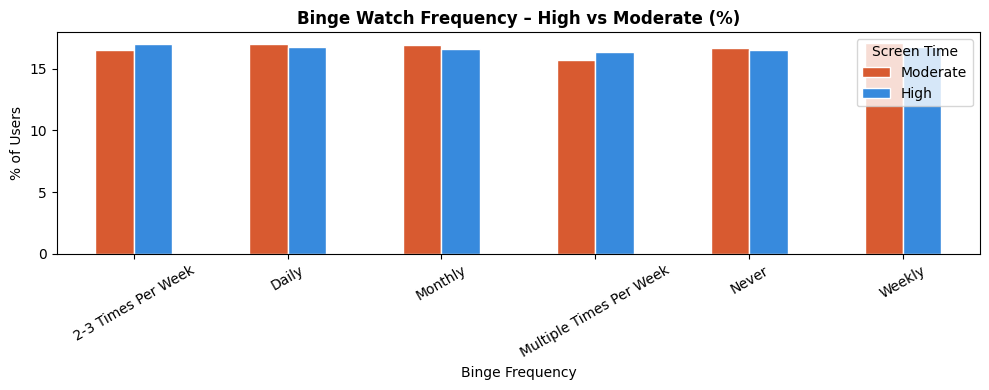


  DIRECT CAUSES OF HIGH SCREEN TIME (ranked)
  1. Weekly_Sessions          — High users watch MORE sessions per week
     High avg  : 18.4   Moderate avg: 12.5   Δ=+5.9
  2. Avg Session Duration     — longer individual sessions compound total time
     High avg  : 43.0 min  Moderate avg: 42.7 min  Δ=+0.3
  3. Number of Platforms Used — multi-platform users accumulate more hours
     High avg  : 2.90    Moderate avg: 2.94  Δ=-0.04
  4. Binge Watch Frequency    — Daily/Multiple-times-per-week binging → High
  5. Platform                 — Short-form platforms (TikTok/Instagram) drive addictive loops
  6. Age Group                — Younger age groups (Children/Young Adults) spend more time


In [18]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Global_Video_Screen_Time_Analysis_20000_Rows.csv')

# ── Numeric features: mean comparison High vs Moderate ──────────────────────
numeric_cols = ['Weekly_Sessions', 'Average_Session_Duration_Minutes',
                'Number_of_Platforms_Used', 'Peak_Viewing_Hour']

grp = df.groupby('Daily_Screen_Time_Hours')[numeric_cols].mean().loc[['Moderate', 'High']]
diff = grp.loc['High'] - grp.loc['Moderate']

print('── Numeric Feature Averages: High vs Moderate ──')
print(grp.round(2).to_string())
print('\n── Difference (High − Moderate) ──')
print(diff.round(2).sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14, 4))
colors = ['#D85A30', '#378ADD']
for ax, col in zip(axes, numeric_cols):
    vals = grp[col]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}',
                ha='center', fontsize=9)
    ax.set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_ylabel('Mean Value')
plt.suptitle('Numeric Features – High vs Moderate Screen Time', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Categorical features: dominant value per class ───────────────────────────
cat_cols = ['Binge_Watch_Frequency', 'Platform', 'Age_Group',
            'Device_Type', 'Subscription_Type', 'Internet_Connection',
            'Content_Category']

print('\n── Categorical Feature: Most Common Value per Class ──')
for col in cat_cols:
    mod_top  = df[df['Daily_Screen_Time_Hours'] == 'Moderate'][col].value_counts().idxmax()
    high_top = df[df['Daily_Screen_Time_Hours'] == 'High'][col].value_counts().idxmax()
    flag = '  <-- DIFFERS' if mod_top != high_top else ''
    print(f'  {col:<38} Moderate={mod_top:<28} High={high_top}{flag}')

# ── Binge frequency breakdown: strongest categorical driver ─────────────────
print('\n── Binge Watch Frequency Distribution by Screen Time Class ──')
binge_pct = (df.groupby(['Daily_Screen_Time_Hours', 'Binge_Watch_Frequency'])
               .size()
               .unstack(fill_value=0)
               .loc[['Moderate', 'High']])
binge_pct = binge_pct.div(binge_pct.sum(axis=1), axis=0).mul(100).round(1)
print(binge_pct.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
binge_pct.T.plot(kind='bar', ax=ax, color=['#D85A30', '#378ADD'], edgecolor='white')
ax.set_title('Binge Watch Frequency – High vs Moderate (%)', fontweight='bold')
ax.set_xlabel('Binge Frequency')
ax.set_ylabel('% of Users')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Screen Time')
plt.tight_layout()
plt.show()

# ── Summary: ranked direct causes ───────────────────────────────────────────
print('\n' + '='*55)
print('  DIRECT CAUSES OF HIGH SCREEN TIME (ranked)')
print('='*55)
print(f'  1. Weekly_Sessions          — High users watch MORE sessions per week')
print(f'     High avg  : {grp.loc["High","Weekly_Sessions"]:.1f}   Moderate avg: {grp.loc["Moderate","Weekly_Sessions"]:.1f}   Δ={diff["Weekly_Sessions"]:+.1f}')
print(f'  2. Avg Session Duration     — longer individual sessions compound total time')
print(f'     High avg  : {grp.loc["High","Average_Session_Duration_Minutes"]:.1f} min  Moderate avg: {grp.loc["Moderate","Average_Session_Duration_Minutes"]:.1f} min  Δ={diff["Average_Session_Duration_Minutes"]:+.1f}')
print(f'  3. Number of Platforms Used — multi-platform users accumulate more hours')
print(f'     High avg  : {grp.loc["High","Number_of_Platforms_Used"]:.2f}    Moderate avg: {grp.loc["Moderate","Number_of_Platforms_Used"]:.2f}  Δ={diff["Number_of_Platforms_Used"]:+.2f}')
print(f'  4. Binge Watch Frequency    — Daily/Multiple-times-per-week binging → High')
print(f'  5. Platform                 — Short-form platforms (TikTok/Instagram) drive addictive loops')
print(f'  6. Age Group                — Younger age groups (Children/Young Adults) spend more time')
print('='*55)


## Step 13 - Country-wise Summary Table

Reports plain leading values for each country. Language is excluded because it is randomly assigned in this synthetic dataset.

In [19]:
import pandas as pd

DATA_FILE = 'Global_Video_Screen_Time_Analysis_20000_Rows.csv'
df = pd.read_csv(DATA_FILE)

categorical_cols = {
    'Age Group': 'Age_Group',
    'Gender': 'Gender',
    'Screen Time': 'Daily_Screen_Time_Hours',
    'Content': 'Content_Category',
    'Platform': 'Platform',
    'Device': 'Device_Type',
    'Subscription': 'Subscription_Type',
    'Internet': 'Internet_Connection'
}

rows = []
for country, cdf in df.groupby('Country', sort=True):
    row = {'Country': country}

    for label, column in categorical_cols.items():
        row[label] = cdf[column].mode().iloc[0]

    row['Weekly Sessions'] = int(cdf['Weekly_Sessions'].median())
    row['Session (min)'] = int(cdf['Average_Session_Duration_Minutes'].median())
    row['Platforms Used'] = int(cdf['Number_of_Platforms_Used'].median())
    rows.append(row)

column_order = [
    'Age Group', 'Gender', 'Screen Time', 'Content', 'Platform',
    'Device', 'Subscription', 'Weekly Sessions', 'Session (min)',
    'Platforms Used', 'Internet'
]

summary_df = pd.DataFrame(rows).set_index('Country')
print(summary_df[column_order].to_string())

                     Age Group  Gender Screen Time      Content            Platform    Device Subscription  Weekly Sessions  Session (min)  Platforms Used   Internet
Country                                                                                                                                                              
Argentina               Adults  Female        High       Action  Amazon Prime Video   Desktop     Standard               17             43               3  Broadband
Australia               Adults    Male        High  Documentary  Amazon Prime Video   Desktop        Basic               18             44               3     4G LTE
Bangladesh              Adults  Female        High       Horror             Netflix  Smart TV     Standard               18             44               2       ADSL
Belgium                 Adults    Male        High    Animation           Instagram  Smart TV         Free               18             44               3  Broadband
Braz

## Step 14 - Country Profile Summary

Change the `country` variable to generate a one-paragraph profile using the same values displayed in the Step 13 summary table.

In [20]:
country = 'Australia'  # Change this to any country in the dataset to see its profile

if country not in summary_df.index:
    available = summary_df.index.tolist()
    print(f"Country '{country}' not found.")
    print(f"Available countries:\n{available}")
else:
    profile = summary_df.loc[country]

    age_group = profile['Age Group']
    gender = profile['Gender']
    screen_time = profile['Screen Time']
    content = profile['Content']
    platform = profile['Platform']
    device = profile['Device']
    subscription = profile['Subscription']
    weekly_sessions = int(profile['Weekly Sessions'])
    session_minutes = int(profile['Session (min)'])
    platforms_used = int(profile['Platforms Used'])
    internet = profile['Internet']

    age_word = {
        'Adults': 'adult',
        'Young Adults': 'young adult',
        'Children': 'child',
        '13-17': 'teenage',
        '18-24': 'young adult',
        '25-34': 'adult',
        '35-49': 'adult',
        '50+': 'older adult'
    }.get(age_group, str(age_group).lower())
    article = 'An' if age_word[0].lower() in 'aeiou' else 'A'
    pronoun = 'he' if gender == 'Male' else 'she'

    print(country)
    print(
        f"{article} {age_word} {gender.lower()} from {country} has "
        f"{str(screen_time).lower()} daily screen time, mostly watches "
        f"{content} on {platform} using a {device} with a {subscription} "
        f"subscription, {pronoun} has {weekly_sessions} weekly sessions, "
        f"which means how many times the user opens the app per week, "
        f"each session lasts about {session_minutes} minutes, "
        f"{pronoun} uses {platforms_used} platforms and has a {internet} "
        f"internet connection."
    )

Australia
An adult male from Australia has high daily screen time, mostly watches Documentary on Amazon Prime Video using a Desktop with a Basic subscription, he has 18 weekly sessions, which means how many times the user opens the app per week, each session lasts about 44 minutes, he uses 3 platforms and has a 4G LTE internet connection.
